<a href="https://colab.research.google.com/github/sindla97/Machine-Learning/blob/main/ML_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Linear Regression From scratch


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/wine-quality-dataset


In [9]:
# import/create a dataset

df=pd.read_csv('/kaggle/input/wine-quality-dataset/WineQT.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [82]:
class LinearRegression():
  def __init__(self, n_iterations=10, learning_rate=0.01) -> None:
    self.n_iterations=n_iterations
    self.learning_rate=learning_rate

  def fit(self,X,y):
    self.X=X
    self.y=y
    if isinstance(self.X, pd.DataFrame)  or isinstance(self.X, np.array):
      self.no_of_features=X.shape[1]
      self.no_of_rows=X.shape[0]
    #intialize weights
    self.coef=np.zeros(self.no_of_features)#np.random.randint(1,100,self.no_of_features).astype(np.float64)
    if isinstance(self.X, pd.DataFrame):
      self.X=self.X.to_numpy()
    if isinstance(self.y, pd.DataFrame):
      self.y=self.y.to_numpy().astype(np.float64)

    self.track_error=[]
    for i in range(self.n_iterations):
      #print(self.X.shape,self.coef.T.shape)
      result = self.predict(self.X)
      #print(result)
      loss=(np.sum((result-self.y)**2))/len(self.y)
      #print(loss)
      error=result-self.y
      self.track_error.append(loss)
      #update coef/weights
      print(self.coef)
      up_coef=(np.matmul(self.X.T,error))/(self.no_of_rows)
      self.coef+=(-self.learning_rate*up_coef.astype(np.float64))


  def predict(self, X):
    return np.matmul(X,self.coef.T)


In [83]:
def normalize(x):
  data=x.copy(deep=True)
  print(data.info())
  for i in range(0,data.shape[1]-1):
    data.iloc[:,i] = ((data.iloc[:,i] - np.mean(data.iloc[:,i]))/np.std(data.iloc[:, i]))
  return data


X=normalize(df.drop(['quality','Id'], axis=1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
dtypes: float64(11)
memory usage: 98.4 KB
None


In [84]:
lr=LinearRegression(n_iterations=10)
lr.fit(X,df['quality'])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 9.82434597e-04 -3.28143932e-03  1.93974361e-03  1.77219317e-04
 -9.99465743e-04 -5.09538489e-04 -1.47674489e-03 -1.41125018e-03
 -4.22494322e-04  2.07578313e-03  5.94939341e-01]
[ 2.41818109e-03 -5.19615763e-03  3.15033861e-03 -1.97157001e-05
 -5.18595903e-04 -6.99775752e-04 -1.72143605e-03  3.59457078e-04
 -2.27044712e-03  3.51147694e-03  5.34185868e-01]
[ 3.74929520e-03 -7.20787829e-03  4.37622044e-03 -1.89696762e-04
 -2.10998755e-04 -9.12354992e-04 -2.08567392e-03  1.76450935e-03
 -3.92114125e-03  4.97546416e-03  5.40396260e-01]
[ 5.03460971e-03 -9.16821286e-03  5.54321383e-03 -3.73160189e-04
  9.29794895e-05 -1.11268374e-03 -2.43153718e-03  3.16755949e-03
 -5.54192451e-03  6.40050478e-03  5.39767619e-01]
[ 6.26990953e-03 -1.10933818e-02  6.66068873e-03 -5.65467401e-04
  3.76762894e-04 -1.30458501e-03 -2.77322314e-03  4.53277007e-03
 -7.11727936e-03  7.79445546e-03  5.39837237e-01]
[ 0.00745736 -0.01298276  0.00772943 -0.0007666   0.00064277 -0.0

In [86]:
lr.predict(X)

,0
0,5.016288
1,5.240080
2,5.253035
3,5.368134
4,5.016288
...,...
1138,5.909194
1139,5.098410
1140,5.603392
1141,5.992456


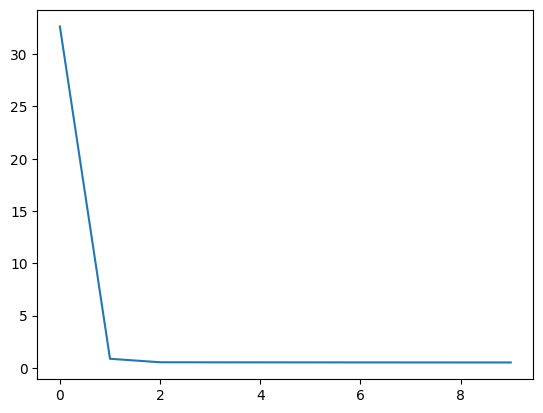

In [85]:
import matplotlib.pyplot as plt
plt.plot(lr.track_error)

## Logistic regression

In [95]:
df['quality_ind']=df['quality'].apply(lambda x: 1 if x>5 else 0)

In [89]:
df['quality_ind'].value_counts()

,count
quality_ind,
1,621
0,522


In [91]:
df['quality_ind']=df['quality_ind'].astype('category')

In [110]:
from sklearn.metrics import accuracy_score

In [111]:
class LogisticRegression():
  def __init__(self, n_iterations=10, learning_rate=0.01) -> None:
    self.n_iterations=n_iterations
    self.learning_rate=learning_rate

  def fit(self,X,y):
    self.X=X
    self.y=y
    if isinstance(self.X, pd.DataFrame)  or isinstance(self.X, np.array):
      self.no_of_features=X.shape[1]
      self.no_of_rows=X.shape[0]
    #intialize weights
    self.coef=np.zeros(self.no_of_features)#np.random.randint(1,100,self.no_of_features).astype(np.float64)
    if isinstance(self.X, pd.DataFrame):
      self.X=self.X.to_numpy()
    if isinstance(self.y, pd.DataFrame):
      self.y=self.y.to_numpy().astype(np.float64)

    self.track_error=[]
    for i in range(self.n_iterations):
      #print(self.X.shape,self.coef.T.shape)
      result,prediction = self.predict(self.X)
      #print(result)
      loss=accuracy_score(prediction,self.y)
      #print(loss)
      error=result-self.y
      self.track_error.append(loss)
      #update coef/weights
      print(self.coef)
      up_coef=(np.matmul(self.X.T,error))/(self.no_of_rows)
      self.coef+=(-self.learning_rate*up_coef.astype(np.float64))


  def predict(self, X):
    pred_prob=1/(1+np.exp(-1*np.matmul(X,self.coef.T)))
    y_pred=np.where(pred_prob>0.5,1,0)
    return pred_prob, y_pred


In [112]:
lr=LogisticRegression(n_iterations=100)
lr.fit(X,df['quality_ind'])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 4.41744977e-04 -1.64771773e-03  7.72805339e-04 -3.85152571e-05
 -5.01114557e-04 -3.51558563e-04 -1.12913840e-03 -7.68374105e-04
  7.59692650e-05  1.16670458e-03  6.89515894e-03]
[ 8.82077988e-04 -3.28511722e-03  1.53895793e-03 -7.71017337e-05
 -9.97539612e-04 -6.99396660e-04 -2.25089458e-03 -1.52698438e-03
  1.49676223e-04  2.32765719e-03  1.18881151e-02]
[ 0.00132063 -0.00491334  0.00229906 -0.00011547 -0.00149049 -0.0010438
 -0.0033663  -0.00227844  0.00022229  0.00348339  0.01550578]
[ 0.00175714 -0.00653323  0.00305357 -0.00015341 -0.00198084 -0.00138497
 -0.0044761  -0.00302462  0.00029463  0.0046343   0.01812901]
[ 0.00219143 -0.0081454   0.00380282 -0.00019077 -0.00246922 -0.00172306
 -0.00558085 -0.00376688  0.0003673   0.00578068  0.02003237]
[ 0.00262338 -0.00975029  0.00454705 -0.00022745 -0.00295608 -0.00205821
 -0.00668094 -0.00450618  0.00044071  0.00692274  0.02141388]
[ 0.00305292 -0.01134823  0.00528644 -0.00026338 -0.00344173 -0.00

In [107]:
lr.predict(X)[1]

array([0, 0, 0, ..., 1, 1, 1])

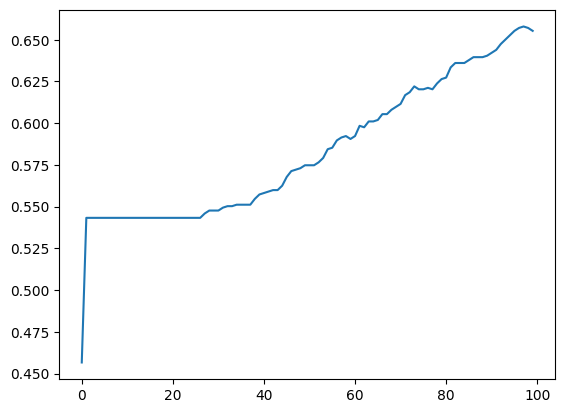

In [113]:
import matplotlib.pyplot as plt
plt.plot(lr.track_error)